# 3.1.1 两室交换与矩阵收支

## 学习目标与先修知识

能从两个室的逐项收支（mass balance）构造向量（vector）与矩阵（matrix），用矩阵乘法（matrix multiplication）计算变化率，并检查内部交换、外部输入（input）与清除的不同作用。

先修：第 2.4 章的时间步更新、收支和数值非负性（nonnegativity）；Python 列表与循环。 [复习上一节](../../02-系统随时间演化/04-数值模拟误差与迁移/03-在输入跳变处分段计算.ipynb)。

## 具体问题

物质从血液一侧进入组织一侧，组织又向血液一侧回流。若将两处的流出都算成全身清除，总量会怎样被错误估计？先用两个理想的充分混合室检验。

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
BLUE, PINK = '#008bfb', '#ff0051'

## 初步实验

先计算一个具体情形，再解释这些数是怎样相互制约的。

In [2]:
A1,A2,a,b=6.,0.,.2,.1
forward,backward=a*A1,b*A2
rate1,rate2=-forward+backward,forward-backward
display(Markdown(show_table(['量','数值 / (U/T)'],[('1→2',forward),('2→1',backward),('室 1 变化率',rate1),('室 2 变化率',rate2),('总变化率',rate1+rate2)])))

| 量 | 数值 / (U/T) |
| --- | --- |
| 1→2 | 1.2 |
| 2→1 | 0 |
| 室 1 变化率 | -1.2 |
| 室 2 变化率 | 1.2 |
| 总变化率 | 0 |

## 模型假设

每个室内充分混合；交换流率（flow rate）正比于来源室所追踪物质总量（tracked amount）；容积固定，不显式模拟空间运输、结合或化学反应。

| 量 | 定义 | 单位 |
|---|---|---|
| A1、A2 | 两个室的总量 | U |
| a、b | 分别对应 1→2、2→1 的交换系数 | 1/T |
| c | 仅室 1 的线性清除系数（elimination rate constant） | 1/T |
| u | 仅进入室 1 的输入速率 | U/T |

封闭比较用 c=u=0；开放比较用 c=0.1/T、u=0.6 U/T。状态（state）顺序始终是 [A1,A2]。

## 数学解释与推导

分别写出每个室的收支：
$$\dot A_1=u-(a+c)A_1+bA_2,\qquad \dot A_2=aA_1-bA_2.$$
上方一点表示对时间求导。向量把有顺序的数放在一起，列向量 $x=(A_1,A_2)^\mathsf T$ 的两个分量仍保留各自物理意义；上标 $\mathsf T$ 表示转置（transpose），把行换为列。矩阵是一张有行、列的系数表，$M_{ij}$ 位于第 i 行、第 j 列。于是
$$\dot x=Mx+\begin{pmatrix}u\\0\end{pmatrix},\qquad M=\begin{pmatrix}-a-c&b\\a&-b\end{pmatrix}.$$
矩阵乘法的第 i 个结果是 $\sum_j M_{ij}x_j$，不是每个元素独立相乘。第一列说明“当前 A1 对两个变化率分别贡献什么”。一个 2×2 矩阵乘两个分量，结果仍有两个分量；M 的单位是 1/T。

线性映射（linear map）满足 $M(\alpha x+\beta z)=\alpha Mx+\beta Mz$。外加非零常向量后整体关系是仿射（affine）的，不能把常输入也随 x 自动缩放。

相加原方程得 $\dot S=u-cA_1$，其中 $S=A_1+A_2$。封闭交换的矩阵**列和**为零，每个内部转移一减一加；只有穿过系统边界（system boundary）的量留下。此结论可直接检查矩阵，也可独立检查累计账目。

显式欧拉法（forward Euler method）使用同一段首状态：$x_{n+1}=x_n+h(Mx_n+[u,0]^\mathsf T)$。先更新 A1 再用更新后的 A1 更新 A2 会破坏这个同步规则。为所有非负状态保证下一步非负，一个充分条件是 $h(a+c)\le1$ 且 $hb\le1$；它还不是精度保证。

若改成浓度（concentration） $C_i=A_i/V_i$，需重新推导：$\dot C_1=u/V_1-(a+c)C_1+b(V_2/V_1)C_2$。总量是 $V_1C_1+V_2C_2$，不能把两个浓度直接相加充当全身总量。

## 核心实现

把刚才的关系逐项写入函数。

In [3]:
def exchange(a, b, c, u, amounts):
    matrix = [[-a-c, b], [a, -b]]
    first, second = amounts
    rates = [u-(a+c)*first+b*second, a*first-b*second]
    return matrix, rates, sum(rates)

def simulate_exchange(a,b,c,u,initial,h,steps):
    matrix=np.array([[-a-c,b],[a,-b]])
    scalar=[list(initial)];vector=[np.array(initial,dtype=float)]
    ledger=[sum(initial)]
    for _ in range(steps):
        x,y=scalar[-1]
        scalar.append([x+h*(u-(a+c)*x+b*y),y+h*(a*x-b*y)])
        vector.append(vector[-1]+h*(matrix@vector[-1]+[u,0]))
        ledger.append(ledger[-1]+h*(u-c*x))
    return np.array(scalar),np.array(vector),np.array(ledger)

## 对照实验

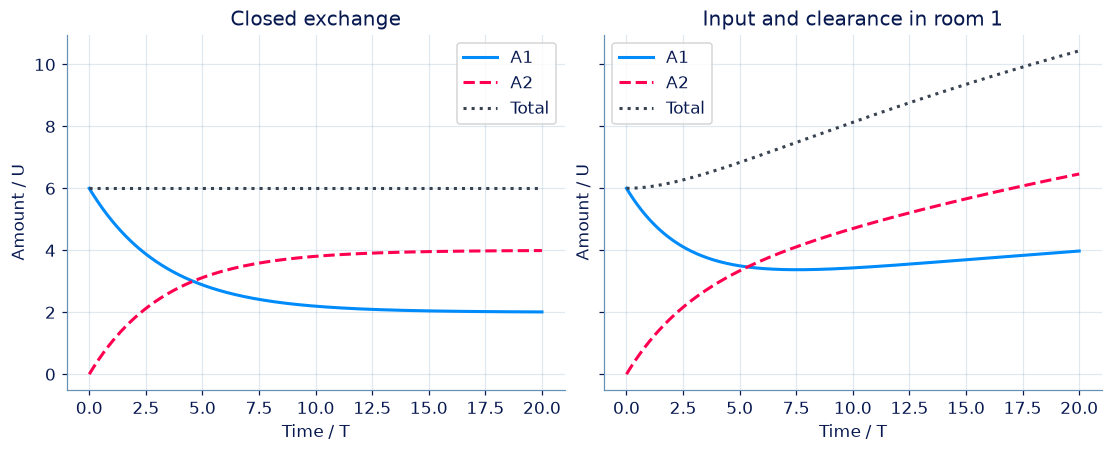

In [4]:
fig,axes=plt.subplots(1,2,figsize=(10,4),sharey=True)
for ax,c,u,title in zip(axes,[0,.1],[0,.6],['Closed exchange','Input and clearance in room 1']):
    scalar,vector,ledger=simulate_exchange(.2,.1,c,u,[6,0],.05,400)
    t=np.arange(len(scalar))*.05
    ax.plot(t,scalar[:,0],color=BLUE,label='A1');ax.plot(t,scalar[:,1],'--',color=PINK,label='A2')
    ax.plot(t,scalar.sum(axis=1),':',color='#384251',label='Total')
    ax.set(xlabel='Time / T',ylabel='Amount / U',title=title);ax.legend()
plt.show()

## 结果解释

封闭图中 A1 减少、A2 增加，总量保持 6 U。开放图中输入与清除只作用于室 1，总量变化由 u−cA1 决定；室间转移并没有额外创造或消灭物质。两室量分别用蓝实线、玫红虚线。

### 独立核对

用逐项收支核对矩阵运算，再用外部累计账目检查总量；这三种表达有助于定位转置和重复计账错误。

In [5]:
for a,b,c,u in [(.2,.1,0,0),(.2,.1,.1,.6),(0,0,0,1),(.2,0,.1,0)]:
    s,m,ledger=simulate_exchange(a,b,c,u,[6,0],.05,100)
    np.testing.assert_allclose(s,m,atol=1e-12)
    np.testing.assert_allclose(s.sum(axis=1),ledger,atol=1e-12)
    assert s.min()>=0
np.testing.assert_allclose(exchange(.2,.1,0,0,[6,0])[1],[-1.2,1.2])
print('标量、矩阵、外部累计账目一致；封闭、开放与断开边界通过。')

标量、矩阵、外部累计账目一致；封闭、开放与断开边界通过。


## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · 多项选择题：交换发生在哪一列

用所追踪物质总量（tracked amount）列向量（vector） x=[A1,A2] 表示两个充分混合的室。a 表示 1→2，b 表示 2→1，均为每单位时间系数。封闭模型（model） x′=Mx 中，哪些说法正确？

- **A.** M=[[-a,b],[a,-b]]。
- **B.** 每一列的和为零，内部交换不改变总量。
- **C.** M 的非对角元素必须为负。
- **D.** 把两条方程相加得到 A1′+A2′=0。

[作答：交换发生在哪一列](http://127.0.0.1:8000/chapters/03-01-%E4%BB%8E%E5%A4%9A%E4%B8%AA%E5%AE%A4%E8%BF%9B%E5%85%A5%E7%BA%BF%E6%80%A7%E4%BB%A3%E6%95%B0/practice/?question=p03-exchange-columns)

### 第 2 题 · Python 计算题：把两室收支写成矩阵

两个室双向交换，恒定输入（input）进入室 1，线性清除也只在室 1。给定当前所追踪物质总量（tracked amount），返回系统矩阵（matrix）、两个室的变化率和总变化率。

**函数与代码模板**

```python
def solve(
    a: float,
    b: float,
    c: float,
    u: float,
    amounts: list[float],
) -> tuple[list[list[float]], list[float], float]:
    # 根据题意计算，并按约定顺序返回。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `a` | `float` | 室 1 到室 2 的交换系数。 | 1/T |
| `b` | `float` | 室 2 到室 1 的交换系数。 | 1/T |
| `c` | `float` | 仅从室 1 清除的系数。 | 1/T |
| `u` | `float` | 仅进入室 1 的恒定输入速率。 | U/T |
| `amounts` | `list[float]` | 按 [A1,A2] 排列的当前总量。 | U |

**返回值**

按以下顺序返回元组：(matrix, rates, total_rate)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `matrix` | `list[list[float]]` | 2×2 矩阵，行对应接收方程，列对应被乘的总量。 | 1/T |
| `rates` | `list[float]` | [A1′,A2′]。 | U/T |
| `total_rate` | `float` | 两个变化率的和。 | U/T |

**计算规则**

M=[[-a-c,b],[a,-b]]；rates=M×amounts+[u,0]；total_rate=sum(rates)。

**约束与边界**

- 所有数值有限；不修改输入列表。
- 0≤a,b,c≤1；0≤u≤5；amounts 长度为 2，各项 0—20。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| a | 室 1 到室 2 的交换系数。 | 0.2 | 1/T |
| b | 室 2 到室 1 的交换系数。 | 0.1 | 1/T |
| c | 仅从室 1 清除的系数。 | 0 | 1/T |
| u | 仅进入室 1 的恒定输入速率。 | 0 | U/T |
| amounts | 按 [A1,A2] 排列的当前总量。 | [6, 0] | U |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
a = 0.2
b = 0.1
c = 0
u = 0
amounts = [6, 0]

result = solve(a, b, c, u, amounts)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| matrix | 2×2 矩阵，行对应接收方程，列对应被乘的总量。 | [[-0.2, 0.1], [0.2, -0.1]] | 1/T |
| rates | [A1′,A2′]。 | [-1.2000000000000002, 1.2000000000000002] | U/T |
| total_rate | 两个变化率的和。 | 0 | U/T |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([[-0.2, 0.1], [0.2, -0.1]],
                   [-1.2000000000000002,
                    1.2000000000000002],
                   0.0)
```

**样例解释**

室 1 每 T 转出 0.2×6=1.2 U，室 2 同时得到 1.2 U；总变化率为零。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：把两室收支写成矩阵](http://127.0.0.1:8000/chapters/03-01-%E4%BB%8E%E5%A4%9A%E4%B8%AA%E5%AE%A4%E8%BF%9B%E5%85%A5%E7%BA%BF%E6%80%A7%E4%BB%A3%E6%95%B0/practice/?question=p03-exchange-balance)

### 第 3 题 · 多项选择题：改用浓度时遗漏了什么

室 1 和室 2 的容积分别为 2 L 和 1 L，所追踪物质总量（tracked amount）为 A1=4 U、A2=2 U。交换项是 aA1 与 bA2。哪些说法正确？

- **A.** 两室浓度（concentration）都为 2 U/L。
- **B.** A1+A2 等于两室浓度之和。
- **C.** 若 C1=A1/V1，C1′=−aC1+b(V2/V1)C2（封闭交换）。
- **D.** 把 A 全换成 C 而保留所有矩阵（matrix）元素，任何容积下都正确。

[作答：改用浓度时遗漏了什么](http://127.0.0.1:8000/chapters/03-01-%E4%BB%8E%E5%A4%9A%E4%B8%AA%E5%AE%A4%E8%BF%9B%E5%85%A5%E7%BA%BF%E6%80%A7%E4%BB%A3%E6%95%B0/practice/?question=p03-amount-concentration)

### 第 4 题 · 单项选择题：增加第三室后怎样检查守恒

三个室仅沿 1→2→3 单向交换，两个系数都为 r>0。状态（state）为所追踪物质总量（tracked amount）列向量（vector）。正确矩阵（matrix）是哪一个？

- **A.** [[-r,0,0],[r,-r,0],[0,r,0]]
- **B.** [[-r,r,0],[0,-r,r],[0,0,0]]
- **C.** [[-r,0,0],[r,r,0],[0,r,0]]
- **D.** [[-r,0,0],[0,-r,0],[0,0,0]]

[作答：增加第三室后怎样检查守恒](http://127.0.0.1:8000/chapters/03-01-%E4%BB%8E%E5%A4%9A%E4%B8%AA%E5%AE%A4%E8%BF%9B%E5%85%A5%E7%BA%BF%E6%80%A7%E4%BB%A3%E6%95%B0/practice/?question=p03-third-room)

**进一步阅读**

[Boyd 与 Vandenberghe：应用线性代数](https://web.stanford.edu/~boyd/vmls/)：向量、范数、独立性与线性方程。